In [1]:
from google.colab import files
uploaded = files.upload()

Saving loan_approval - loan_approval.csv to loan_approval - loan_approval.csv


In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading Dataset
df = pd.read_csv("/content/loan_approval - loan_approval.csv")

# First 5 rows
print(df.head())

              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  


In [4]:
# Shape of Data
print(df.shape)

(2000, 8)


In [5]:
# Data Types
print(df.dtypes)

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


In [6]:
# Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


In [7]:
# Missing Values
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [8]:
# Identify Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['name', 'city'], dtype='object')


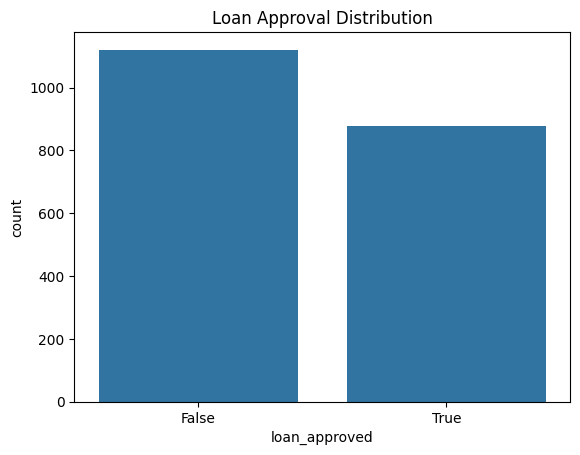

In [9]:
# EDA

# Distribution of Target Variables
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()

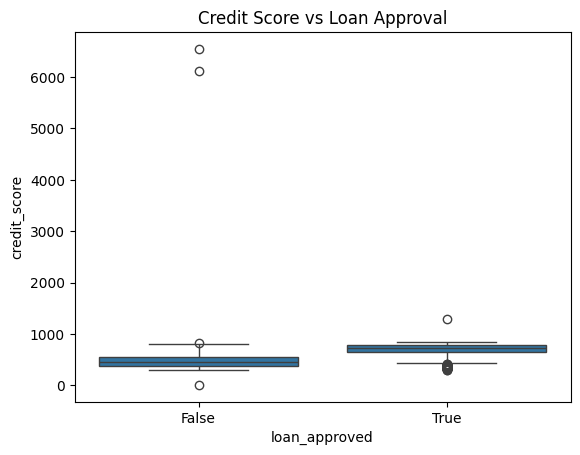

In [10]:
# Numerical features vs Target Variable
sns.boxplot(x='loan_approved',
            y='credit_score',
            data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

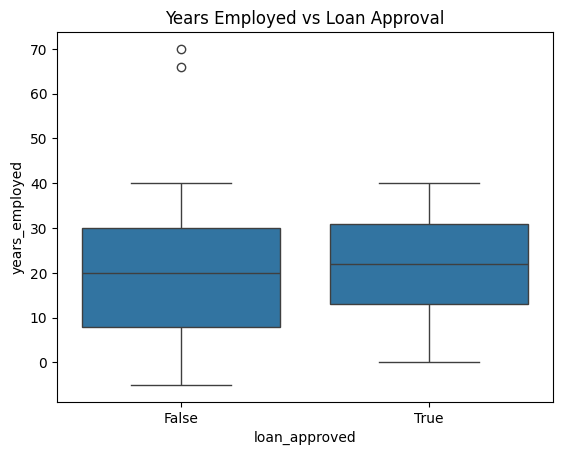

In [11]:
# Years of Employment vs Target Variable
sns.boxplot(x='loan_approved',
            y='years_employed',
            data=df)
plt.title("Years Employed vs Loan Approval")
plt.show()

In [12]:
# Outliers Detection and Treatment

# Detect Outliers using IQR
numerical_cols = ['income',
                  'credit_score',
                  'loan_amount',
                  'years_employed',
                  'points']

for col in numerical_cols:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 -Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  Outliers = df[(df[col]<lower_bound)| (df[col]>upper_bound)]

print(col, "Outliers:", len(Outliers))

points Outliers: 0


In [13]:
# Outliers Treatment (Capping)

for col in numerical_cols:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

In [14]:
# Convert Target Variable & Drop Unnecessary Columns

# Convert Boolean to Numeric
df['loan_approved'] = df['loan_approved'].astype(int)

# Drop Unnecessary Columns
df['loan_approved'] = df['loan_approved'].astype(int)

In [19]:
# Feature Selection and Data Splitting

# Independent & Dependent Variables
X = df.drop(['loan_approved', 'name', 'city'], axis=1)
y = df['loan_approved']

# Train-Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
# Logistic Regression Model Building

# Train Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [23]:
# Prediction
y_pred = model.predict(x_test_scaled)

print(y_pred[:10])

[1 0 1 1 0 1 0 1 0 0]


[[224   0]
 [  0 176]]


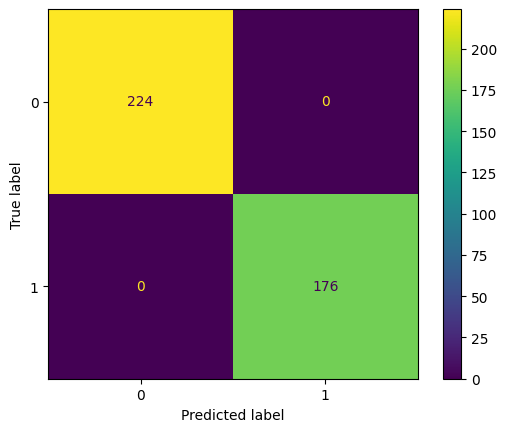

In [24]:
# Model Evaluation – Confusion Matrix

# Generate Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

b) Interpretation
True Negatives = 224
False Positives = 0
False Negatives = 0
True Positives = 176

The model classified every test record correctly.

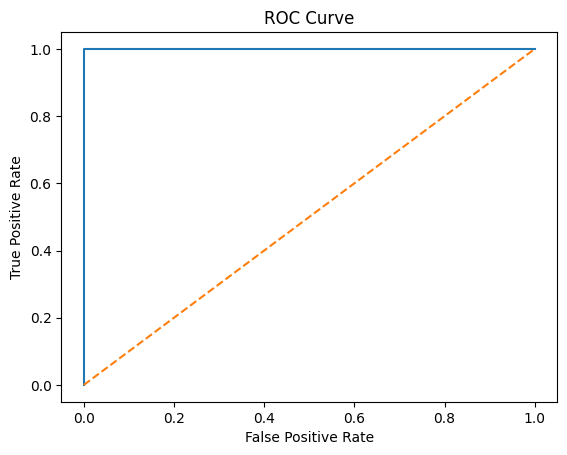

In [25]:
# ROC Curve & AUC

# ROC Curve
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(x_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [26]:
# AUC Score
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 1.0
